Loading Qwen2-0.5B on cpu...
Loaded pretrained model Qwen2-0.5B into HookedTransformer
Computing baselines...
Clean logit diff (Europe - Japan): 2.0107
Corrupted logit diff: -2.4492

Ablating layer 17 (zeroing residual at final token)...
Ablated logit diff: 0.8700
Damage (relative drop): 0.5673 (56.7%)

Sweeping over layers to measure damage...


100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:11<00:00,  2.15it/s]


Sweep results saved to layer_ablation_sweep.csv

===== Full Ablation Results =====
    layer  ablated_diff  damage
0       0        0.5379  0.7325
1       1        1.7594  0.1250
2       2       -0.0949  1.0472
3       3        0.8266  0.5889
4       4        0.6389  0.6822
5       5        1.6355  0.1866
6       6        0.7887  0.6078
7       7        0.8263  0.5891
8       8       -1.5259  1.7589
9       9        2.7220 -0.3537
10     10       -4.0037  2.9911
11     11       -0.7457  1.3708
12     12        0.6460  0.6787
13     13       -3.7247  2.8524
14     14        0.1528  0.9240
15     15       -1.9490  1.9693
16     16        2.2331 -0.1106
17     17        0.8700  0.5673
18     18       -1.8209  1.9056
19     19        1.2659  0.3704
20     20       -5.5020  3.7363
21     21        0.0784  0.9610
22     22        1.8102  0.0997
23     23        0.0000  1.0000

--- Top 3 most damaging layers ---
Layer 20: damage = 3.7363 (ablated diff = -5.5020)
Layer 10: damage = 2.9911 (ab

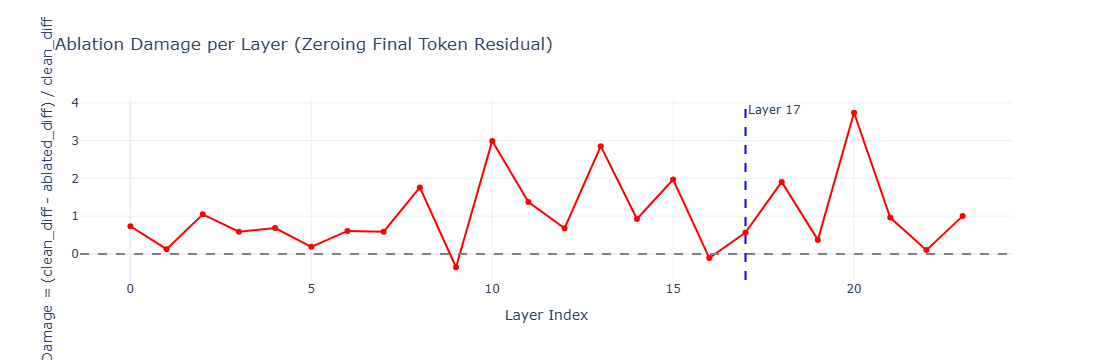

In [4]:


import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from transformer_lens import HookedTransformer
from tqdm import tqdm

MODEL_NAME = "Qwen2-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

CLEAN_PROMPT = "I am using the Euro, so I am in"
CORRUPTED_PROMPT = "I am using the Yen, so I am in"
TARGET_EUROPE = " Europe"
TARGET_JAPAN = " Japan"


print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,
    center_writing_weights=False
)
tokenizer = model.tokenizer

europe_tok = tokenizer.encode(TARGET_EUROPE, add_special_tokens=False)
japan_tok = tokenizer.encode(TARGET_JAPAN, add_special_tokens=False)
if len(europe_tok) != 1 or len(japan_tok) != 1:
    raise ValueError(f"Targets must be single tokens. Europe: {europe_tok}, Japan: {japan_tok}")
europe_id = europe_tok[0]
japan_id = japan_tok[0]


def logit_diff(logits, pos_id, neg_id):
    return logits[pos_id] - logits[neg_id]

def get_clean_baseline():
    tokens = tokenizer.encode(CLEAN_PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = model(tokens)[0, -1, :]
    diff = logit_diff(logits, europe_id, japan_id)
    return logits, diff

def get_corrupted_baseline():
    tokens = tokenizer.encode(CORRUPTED_PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = model(tokens)[0, -1, :]
    diff = logit_diff(logits, europe_id, japan_id)
    return logits, diff

def ablate_layer(layer):
    tokens = tokenizer.encode(CLEAN_PROMPT, return_tensors="pt").to(DEVICE)
    hook_point = f"blocks.{layer}.hook_resid_post"

    def ablation_hook(value, hook):
        value[0, -1, :] = 0.0
        return value

    with model.hooks(fwd_hooks=[(hook_point, ablation_hook)]):
        with torch.no_grad():
            logits = model(tokens)
    final_logits = logits[0, -1, :]
    diff = logit_diff(final_logits, europe_id, japan_id)
    return final_logits, diff


print("Computing baselines...")
clean_logits, clean_diff = get_clean_baseline()
corrupted_logits, corrupted_diff = get_corrupted_baseline()
print(f"Clean logit diff (Europe - Japan): {clean_diff:.4f}")
print(f"Corrupted logit diff: {corrupted_diff:.4f}")

target_layer = 17
print(f"\nAblating layer {target_layer} (zeroing residual at final token)...")
ablated_logits, ablated_diff = ablate_layer(target_layer)
print(f"Ablated logit diff: {ablated_diff:.4f}")
damage = (clean_diff - ablated_diff) / clean_diff
print(f"Damage (relative drop): {damage:.4f} ({damage*100:.1f}%)")


n_layers = model.cfg.n_layers
ablation_diffs = []
ablation_damages = []

print("\nSweeping over layers to measure damage...")
for layer in tqdm(range(n_layers)):
    _, diff = ablate_layer(layer)
    diff_float = float(diff.cpu().item() if hasattr(diff, 'cpu') else diff)
    ablation_diffs.append(diff_float)
    damage_val = (clean_diff - diff_float) / clean_diff
    ablation_damages.append(float(damage_val))


df = pd.DataFrame({
    "layer": list(range(n_layers)),
    "ablated_diff": ablation_diffs,
    "damage": ablation_damages
})
df.to_csv("layer_ablation_sweep.csv", index=False)
print("\nSweep results saved to layer_ablation_sweep.csv")


print("\n===== Full Ablation Results =====")
print(df.to_string(float_format="%.4f"))

print("\n--- Top 3 most damaging layers ---")
top_damage = df.nlargest(3, "damage")
for _, row in top_damage.iterrows():
    print(f"Layer {int(row['layer'])}: damage = {row['damage']:.4f} (ablated diff = {row['ablated_diff']:.4f})")


fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df["layer"],
    y=df["damage"],
    mode="lines+markers",
    name="Damage (relative drop)",
    line=dict(color="red", width=2),
    marker=dict(size=6)
))
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_vline(x=target_layer, line_dash="dash", line_color="blue", annotation_text=f"Layer {target_layer}")

fig.update_layout(
    title="Ablation Damage per Layer (Zeroing Final Token Residual)",
    xaxis_title="Layer Index",
    yaxis_title="Damage = (clean_diff - ablated_diff) / clean_diff",
    template="plotly_white"
)

fig.write_html("layer_ablation_sweep.html")
print("\nInteractive plot saved to layer_ablation_sweep.html")
fig.show()